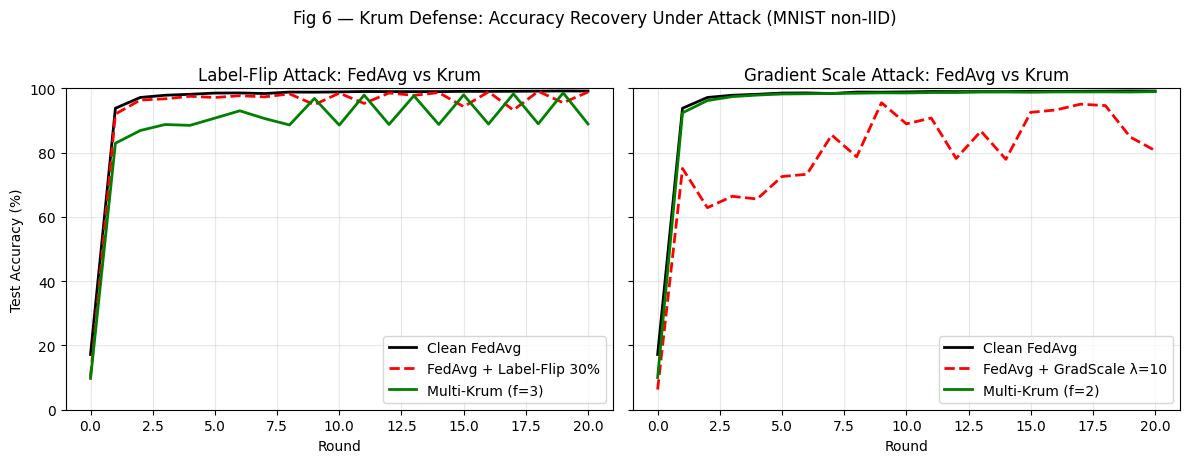

✓ fig6_krum_recovery.png saved


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

RESULTS = "../../experiments/results/"
FIGURES = "../../report/figures/"

# Load round-by-round CSVs — filenames match what run_defenses.py actually saved
baseline     = pd.read_csv(RESULTS + "baseline_mnist.csv")

# Label-flip: FedAvg attacked vs Krum defended (30% malicious = f=3)
lf30_fedavg  = pd.read_csv(RESULTS + "label_flip_fedavg_f30.csv")
lf30_krum    = pd.read_csv(RESULTS + "label_flip_krum_f30.csv")

# Gradient scaling λ=10: FedAvg attacked vs Krum defended (20% malicious = f=2)
gs10_fedavg  = pd.read_csv(RESULTS + "grad_scale_10_fedavg_f20.csv")
gs10_krum    = pd.read_csv(RESULTS + "grad_scale_10_krum_f20.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

# ── Left plot — Label-Flip defense ────────────────────────────
ax = axes[0]
ax.plot(baseline['round'],   baseline['accuracy'] * 100,   'k-',  lw=2, label='Clean FedAvg')
ax.plot(lf30_fedavg['round'], lf30_fedavg['accuracy'] * 100, 'r--', lw=2, label='FedAvg + Label-Flip 30%')
ax.plot(lf30_krum['round'],   lf30_krum['accuracy'] * 100,   'g-',  lw=2, label='Multi-Krum (f=3)')
ax.set_title('Label-Flip Attack: FedAvg vs Krum')
ax.set_xlabel('Round'); ax.set_ylabel('Test Accuracy (%)')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(0, 100)

# ── Right plot — Gradient Scaling defense ─────────────────────
ax = axes[1]
ax.plot(baseline['round'],    baseline['accuracy'] * 100,    'k-',  lw=2, label='Clean FedAvg')
ax.plot(gs10_fedavg['round'], gs10_fedavg['accuracy'] * 100, 'r--', lw=2, label='FedAvg + GradScale λ=10')
ax.plot(gs10_krum['round'],   gs10_krum['accuracy'] * 100,   'g-',  lw=2, label='Multi-Krum (f=2)')
ax.set_title('Gradient Scale Attack: FedAvg vs Krum')
ax.set_xlabel('Round')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(0, 100)

fig.suptitle('Fig 6 — Krum Defense: Accuracy Recovery Under Attack (MNIST non-IID)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES + "fig6_krum_recovery.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig6_krum_recovery.png saved")